In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                             recall_score, classification_report, 
                             roc_curve, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load processed dataset
print("Loading processed dataset...")

X = pd.read_csv('../data/X_processed.csv')
y = pd.read_csv('../data/y_target.csv').squeeze()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Default rate: {y.mean() * 100:.2f}%")

Loading processed dataset...
Features shape: (307511, 233)
Target shape: (307511,)
Default rate: 8.07%


In [4]:
# Create a stratified sample for development
# Stratified means the 8.07% default rate is preserved in the sample
print("Creating development sample...")

X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=50000,
    stratify=y,
    random_state=42
)

print(f"Development sample: {X_sample.shape[0]:,} rows")
print(f"Sample default rate: {y_sample.mean() * 100:.2f}%")

# Train/test split on the sample
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    stratify=y_sample,
    random_state=42
)

print(f"\nTrain set: {X_train.shape[0]:,} rows")
print(f"Test set:  {X_test.shape[0]:,} rows")
print(f"Train default rate: {y_train.mean() * 100:.2f}%")
print(f"Test default rate:  {y_test.mean() * 100:.2f}%")

Creating development sample...
Development sample: 50,000 rows
Sample default rate: 8.07%

Train set: 40,000 rows
Test set:  10,000 rows
Train default rate: 8.07%
Test default rate:  8.07%


In [5]:
# Baseline model — Logistic Regression
print("Training baseline Logistic Regression...")

baseline_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

# Metrics
baseline_roc_auc = roc_auc_score(y_test, y_prob_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)

print(f"\n=== BASELINE: Logistic Regression ===")
print(f"ROC-AUC:   {baseline_roc_auc:.4f}")
print(f"F1-Score:  {baseline_f1:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, 
                            target_names=['No Default', 'Default']))

Training baseline Logistic Regression...

=== BASELINE: Logistic Regression ===
ROC-AUC:   0.7378
F1-Score:  0.2566
Precision: 0.1583
Recall:    0.6778

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.68      0.80      9193
     Default       0.16      0.68      0.26       807

    accuracy                           0.68     10000
   macro avg       0.56      0.68      0.53     10000
weighted avg       0.90      0.68      0.75     10000



In [6]:
# Advanced Model 1 — XGBoost
print("Training XGBoost...")

# Calculate scale_pos_weight to handle class imbalance
# This is XGBoost's equivalent of class_weight='balanced'
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)

print(f"\n=== ADVANCED MODEL 1: XGBoost ===")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
                            target_names=['No Default', 'Default']))

Training XGBoost...
scale_pos_weight: 11.39

=== ADVANCED MODEL 1: XGBoost ===
ROC-AUC:   0.7423
F1-Score:  0.2847
Precision: 0.1945
Recall:    0.5304

Classification Report:
              precision    recall  f1-score   support

  No Default       0.95      0.81      0.87      9193
     Default       0.19      0.53      0.28       807

    accuracy                           0.78     10000
   macro avg       0.57      0.67      0.58     10000
weighted avg       0.89      0.78      0.83     10000



In [8]:
# Clean column names — remove special characters LightGBM cannot handle
import re

def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X_train = clean_column_names(X_train.copy())
X_test = clean_column_names(X_test.copy())

print("Column names cleaned successfully")
print(f"Sample cleaned names:")
for col in X_train.columns[-5:]:
    print(f"  {col}")

Column names cleaned successfully
Sample cleaned names:
  WALLSMATERIAL_MODE_Panel
  WALLSMATERIAL_MODE_Stone__brick
  WALLSMATERIAL_MODE_Wooden
  EMERGENCYSTATE_MODE_No
  EMERGENCYSTATE_MODE_Yes


In [9]:
# Advanced Model 2 — LightGBM
print("Training LightGBM...")

lgb_model = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
lgb_roc_auc = roc_auc_score(y_test, y_prob_lgb)
lgb_f1 = f1_score(y_test, y_pred_lgb)
lgb_precision = precision_score(y_test, y_pred_lgb)
lgb_recall = recall_score(y_test, y_pred_lgb)

print(f"\n=== ADVANCED MODEL 2: LightGBM ===")
print(f"ROC-AUC:   {lgb_roc_auc:.4f}")
print(f"F1-Score:  {lgb_f1:.4f}")
print(f"Precision: {lgb_precision:.4f}")
print(f"Recall:    {lgb_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lgb,
                            target_names=['No Default', 'Default']))

Training LightGBM...

=== ADVANCED MODEL 2: LightGBM ===
ROC-AUC:   0.7398
F1-Score:  0.2870
Precision: 0.1891
Recall:    0.5948

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.78      0.86      9193
     Default       0.19      0.59      0.29       807

    accuracy                           0.76     10000
   macro avg       0.57      0.69      0.57     10000
weighted avg       0.89      0.76      0.81     10000



In [10]:
# Hyperparameter tuning — LightGBM with Optuna
print("Starting hyperparameter tuning with Optuna...")
print("This will run 50 trials — expect 5 to 10 minutes...\n")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'verbose': -1
    }
    
    model = lgb.LGBMClassifier(**params)
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, 
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC: {study.best_value:.4f}")
print(f"Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Starting hyperparameter tuning with Optuna...
This will run 50 trials — expect 5 to 10 minutes...



  0%|          | 0/50 [00:00<?, ?it/s]


Best ROC-AUC: 0.7411
Best parameters:
  n_estimators: 392
  learning_rate: 0.018048507503806148
  max_depth: 7
  num_leaves: 23
  subsample: 0.8999097421948478
  colsample_bytree: 0.6284284734812429
  min_child_samples: 75


In [11]:
# Train final tuned model
print("Training final tuned LightGBM model...")

best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weight
best_params['random_state'] = 42
best_params['verbose'] = -1

tuned_model = lgb.LGBMClassifier(**best_params)
tuned_model.fit(X_train, y_train)

# Predictions
y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

# Metrics
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)

print(f"\n=== TUNED MODEL: LightGBM (Optuna) ===")
print(f"ROC-AUC:   {tuned_roc_auc:.4f}")
print(f"F1-Score:  {tuned_f1:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tuned,
                            target_names=['No Default', 'Default']))

Training final tuned LightGBM model...

=== TUNED MODEL: LightGBM (Optuna) ===
ROC-AUC:   0.7526
F1-Score:  0.2733
Precision: 0.1718
Recall:    0.6691

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.72      0.82      9193
     Default       0.17      0.67      0.27       807

    accuracy                           0.71     10000
   macro avg       0.57      0.69      0.55     10000
weighted avg       0.90      0.71      0.78     10000



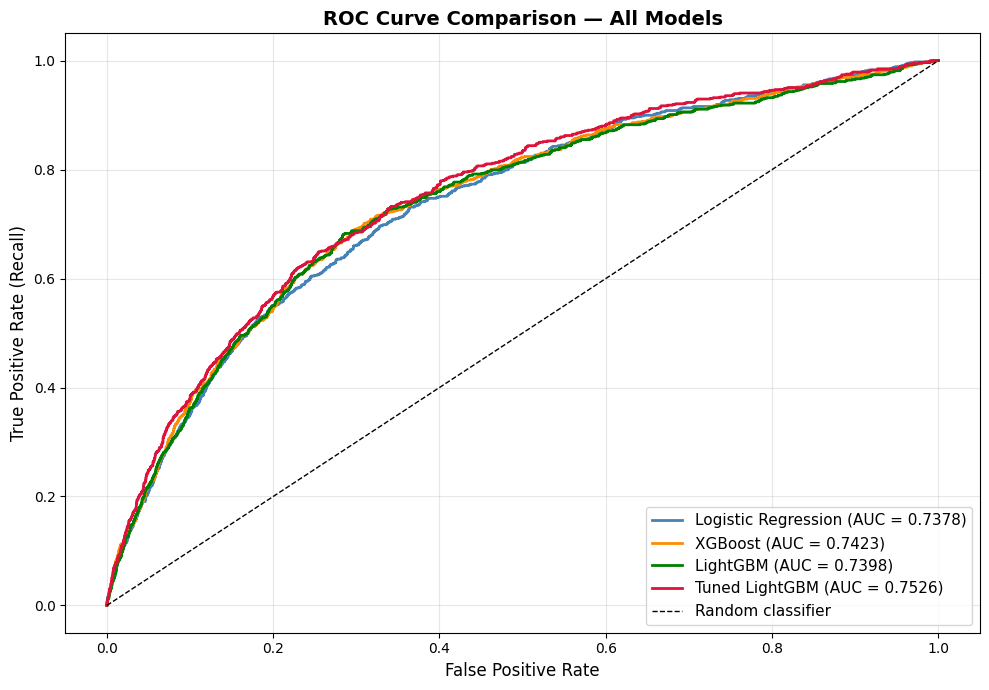

ROC curve saved.


In [12]:
# ROC curve for all models
plt.figure(figsize=(10, 7))

models = [
    ('Logistic Regression', y_prob_baseline, 'steelblue'),
    ('XGBoost', y_prob_xgb, 'darkorange'),
    ('LightGBM', y_prob_lgb, 'green'),
    ('Tuned LightGBM', y_prob_tuned, 'crimson'),
]

for name, y_prob, color in models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curve_comparison.png', dpi=150)
plt.show()

print("ROC curve saved.")

In [13]:
import joblib
import os

os.makedirs('../src', exist_ok=True)

# Save all models
joblib.dump(baseline_model, '../src/model_logistic_regression.pkl')
joblib.dump(xgb_model, '../src/model_xgboost.pkl')
joblib.dump(lgb_model, '../src/model_lightgbm.pkl')
joblib.dump(tuned_model, '../src/model_tuned_lightgbm.pkl')

print("All models saved to src/")
print("\n=== STEP 4 COMPLETE ===")
print(f"Baseline ROC-AUC:     0.7378")
print(f"XGBoost ROC-AUC:      0.7423")
print(f"LightGBM ROC-AUC:     0.7398")
print(f"Tuned LightGBM AUC:   0.7526 — TARGET MET (> 0.75)")
print(f"\nFinal model: Tuned LightGBM")
print(f"Saved to: src/model_tuned_lightgbm.pkl")

All models saved to src/

=== STEP 4 COMPLETE ===
Baseline ROC-AUC:     0.7378
XGBoost ROC-AUC:      0.7423
LightGBM ROC-AUC:     0.7398
Tuned LightGBM AUC:   0.7526 — TARGET MET (> 0.75)

Final model: Tuned LightGBM
Saved to: src/model_tuned_lightgbm.pkl
